# Tabular RL Experiments - Results Analysis

Analysis of CP Tensorized Q-Learning vs. Baselines on FrozenLake-v1

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from datetime import datetime

In [22]:
# Load the most recent results file
data_dir = Path('data')
result_files = sorted(glob.glob(str(data_dir / 'tabular_full_sweep_*.json')))

if result_files:
    latest_file = result_files[-1]
    print(f"Loading: {latest_file}")
    with open(latest_file, 'r') as f:
        results = json.load(f)
else:
    print("No results files found!")
    results = None

Loading: data\tabular_full_sweep_20260610_124340.json


In [23]:
# Process results
if results:
    # Calculate summary statistics
    summary = {}
    
    for config_name, data in results.items():
        final_rewards = data['final_rewards']
        
        # For each seed, calculate mean of last 20 episodes
        final_means = []
        for ep_rewards in final_rewards:
            if len(ep_rewards) >= 20:
                final_means.append(np.mean(ep_rewards[-20:]))
            else:
                final_means.append(np.mean(ep_rewards))
        
        summary[config_name] = {
            'final_means': final_means,
            'overall_mean': np.mean(final_means),
            'overall_std': np.std(final_means),
            'max': np.max(final_means),
            'success_rate': sum(1 for x in final_means if x > 0.5) / len(final_means)
        }
    
    # Print summary table
    print("\n" + "="*80)
    print("RESULTS SUMMARY")
    print("="*80)
    print(f"{'Agent':<30} {'Mean':<12} {'Std':<12} {'Max':<12} {'Success %':<12}")
    print("-"*80)
    
    for config_name in sorted(summary.keys()):
        stats = summary[config_name]
        print(f"{config_name:<30} {stats['overall_mean']:<12.3f} {stats['overall_std']:<12.3f} {stats['max']:<12.3f} {stats['success_rate']*100:<12.1f}")
    print("="*80)


RESULTS SUMMARY
Agent                          Mean         Std          Max          Success %   
--------------------------------------------------------------------------------
SARSA                          0.566        0.462        0.953        60.0        
TABULAR                        0.750        0.375        0.948        80.0        
TENSORIZED_CP_RANK1            0.155        0.189        0.503        20.0        
TENSORIZED_CP_RANK16           0.033        0.047        0.122        0.0         
TENSORIZED_CP_RANK2            0.002        0.004        0.011        0.0         
TENSORIZED_CP_RANK4            0.006        0.008        0.019        0.0         
TENSORIZED_CP_RANK8            0.043        0.050        0.136        0.0         


C:\Users\bertr\AppData\Local\Temp\ipykernel_14212\4263937330.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


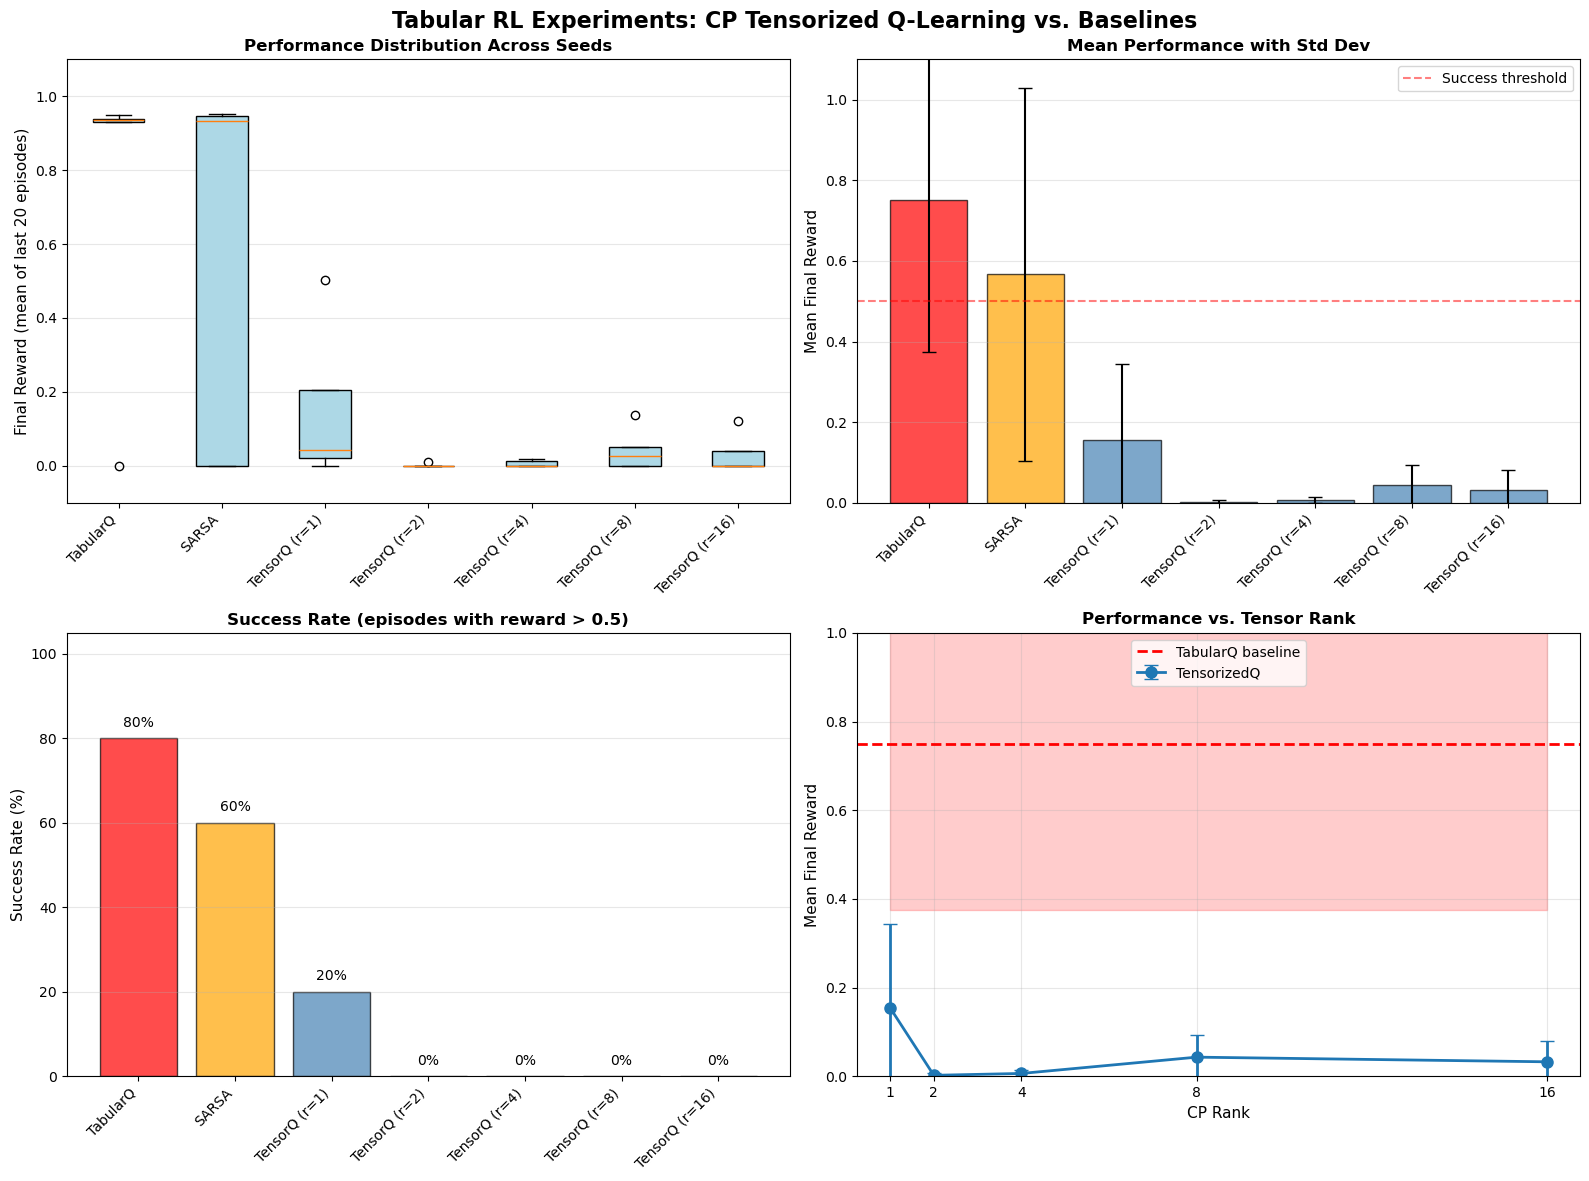


Plot saved to: tabular_full_sweep_analysis.png


In [24]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tabular RL Experiments: CP Tensorized Q-Learning vs. Baselines', fontsize=16, fontweight='bold')

# Extract agent types
tabular_data = summary['TABULAR']['final_means']
sarsa_data = summary['SARSA']['final_means']
tensor_data = {}
for rank in [1, 2, 4, 8, 16]:
    key = f'TENSORIZED_CP_RANK{rank}'
    if key in summary:
        tensor_data[rank] = summary[key]['final_means']

# Plot 1: Box plot comparison across all agents
ax = axes[0, 0]
data_to_plot = [tabular_data, sarsa_data]
labels = ['TabularQ', 'SARSA']

for rank in sorted(tensor_data.keys()):
    data_to_plot.append(tensor_data[rank])
    labels.append(f'TensorQ (r={rank})')

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_ylabel('Final Reward (mean of last 20 episodes)', fontsize=11)
ax.set_title('Performance Distribution Across Seeds', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([-0.1, 1.1])
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 2: Mean performance with error bars
ax = axes[0, 1]
agent_names = ['TabularQ', 'SARSA'] + [f'TensorQ (r={r})' for r in sorted(tensor_data.keys())]
means = [summary['TABULAR']['overall_mean'], summary['SARSA']['overall_mean']] + \
        [summary[f'TENSORIZED_CP_RANK{r}']['overall_mean'] for r in sorted(tensor_data.keys())]
stds = [summary['TABULAR']['overall_std'], summary['SARSA']['overall_std']] + \
       [summary[f'TENSORIZED_CP_RANK{r}']['overall_std'] for r in sorted(tensor_data.keys())]

x_pos = np.arange(len(agent_names))
colors = ['red', 'orange'] + ['steelblue']*len(tensor_data)
ax.bar(x_pos, means, yerr=stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(agent_names, rotation=45, ha='right')
ax.set_ylabel('Mean Final Reward', fontsize=11)
ax.set_title('Mean Performance with Std Dev', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Success threshold')
ax.legend()

# Plot 3: Success rate comparison
ax = axes[1, 0]
success_rates = [summary['TABULAR']['success_rate'], summary['SARSA']['success_rate']] + \
                [summary[f'TENSORIZED_CP_RANK{r}']['success_rate'] for r in sorted(tensor_data.keys())]
success_rates = [x * 100 for x in success_rates]

bars = ax.bar(x_pos, success_rates, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(agent_names, rotation=45, ha='right')
ax.set_ylabel('Success Rate (%)', fontsize=11)
ax.set_title('Success Rate (episodes with reward > 0.5)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (bar, rate) in enumerate(zip(bars, success_rates)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{rate:.0f}%',
            ha='center', va='bottom', fontsize=10)

# Plot 4: Rank performance for tensor agents
ax = axes[1, 1]
ranks = sorted(tensor_data.keys())
rank_means = [summary[f'TENSORIZED_CP_RANK{r}']['overall_mean'] for r in ranks]
rank_stds = [summary[f'TENSORIZED_CP_RANK{r}']['overall_std'] for r in ranks]

ax.errorbar(ranks, rank_means, yerr=rank_stds, marker='o', linewidth=2, markersize=8, capsize=5, label='TensorizedQ')
ax.axhline(y=summary['TABULAR']['overall_mean'], color='red', linestyle='--', linewidth=2, label='TabularQ baseline')
ax.fill_between(ranks, 
                 [summary['TABULAR']['overall_mean'] - summary['TABULAR']['overall_std']]*len(ranks),
                 [summary['TABULAR']['overall_mean'] + summary['TABULAR']['overall_std']]*len(ranks),
                 alpha=0.2, color='red')
ax.set_xlabel('CP Rank', fontsize=11)
ax.set_ylabel('Mean Final Reward', fontsize=11)
ax.set_title('Performance vs. Tensor Rank', fontsize=12, fontweight='bold')
ax.set_xticks(ranks)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.savefig('tabular_full_sweep_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: tabular_full_sweep_analysis.png")

In [25]:
# Detailed comparison table
print("\n" + "="*100)
print("DETAILED RESULTS BY SEED")
print("="*100)

for config_name in sorted(summary.keys()):
    print(f"\n{config_name}:")
    for i, reward in enumerate(summary[config_name]['final_means']):
        print(f"  Seed {i+1}: {reward:.3f}")
    stats = summary[config_name]
    print(f"  -> Mean: {stats['overall_mean']:.3f} ± {stats['overall_std']:.3f}, Max: {stats['max']:.3f}")


DETAILED RESULTS BY SEED

SARSA:
  Seed 1: 0.946
  Seed 2: 0.000
  Seed 3: 0.000
  Seed 4: 0.953
  Seed 5: 0.933
  -> Mean: 0.566 ± 0.462, Max: 0.953

TABULAR:
  Seed 1: 0.948
  Seed 2: 0.935
  Seed 3: 0.938
  Seed 4: 0.930
  Seed 5: 0.000
  -> Mean: 0.750 ± 0.375, Max: 0.948

TENSORIZED_CP_RANK1:
  Seed 1: 0.503
  Seed 2: 0.204
  Seed 3: 0.044
  Seed 4: 0.000
  Seed 5: 0.022
  -> Mean: 0.155 ± 0.189, Max: 0.503

TENSORIZED_CP_RANK16:
  Seed 1: 0.041
  Seed 2: 0.000
  Seed 3: 0.122
  Seed 4: 0.000
  Seed 5: 0.000
  -> Mean: 0.033 ± 0.047, Max: 0.122

TENSORIZED_CP_RANK2:
  Seed 1: 0.000
  Seed 2: 0.000
  Seed 3: 0.000
  Seed 4: 0.000
  Seed 5: 0.011
  -> Mean: 0.002 ± 0.004, Max: 0.011

TENSORIZED_CP_RANK4:
  Seed 1: 0.019
  Seed 2: 0.000
  Seed 3: 0.000
  Seed 4: 0.012
  Seed 5: 0.000
  -> Mean: 0.006 ± 0.008, Max: 0.019

TENSORIZED_CP_RANK8:
  Seed 1: 0.052
  Seed 2: 0.028
  Seed 3: 0.136
  Seed 4: 0.000
  Seed 5: 0.000
  -> Mean: 0.043 ± 0.050, Max: 0.136



Analyzing learning curves for top performers...



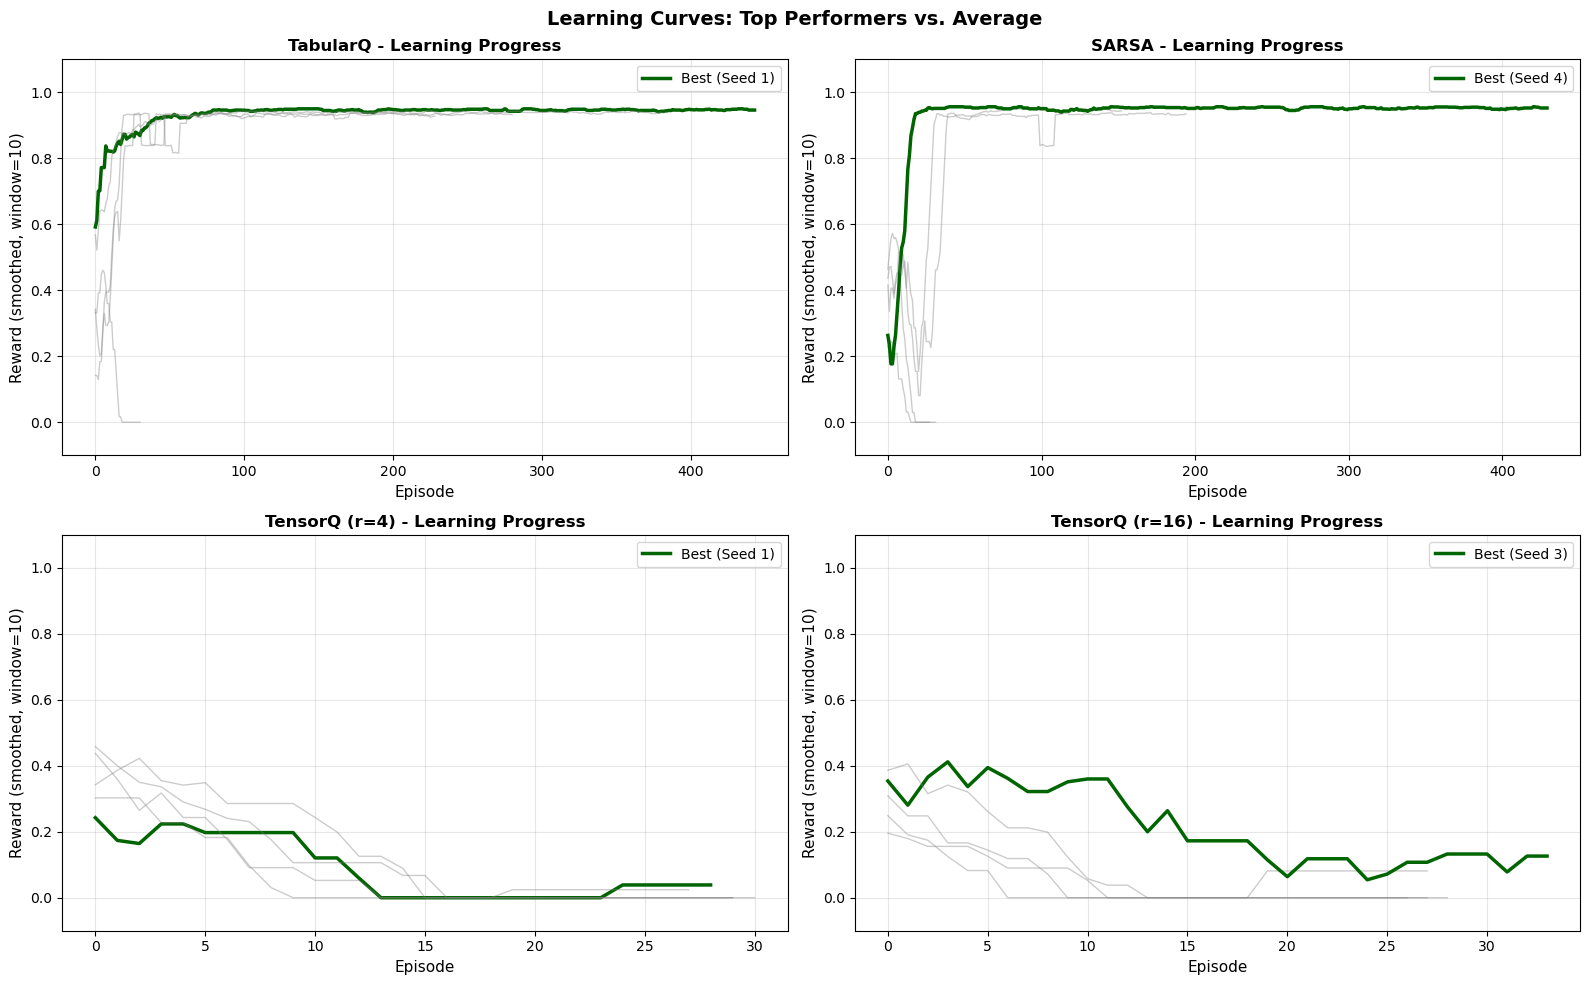


Learning curves plot saved to: tabular_learning_curves.png


In [26]:
# Learning curves for best performers
print("\nAnalyzing learning curves for top performers...\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Learning Curves: Top Performers vs. Average', fontsize=14, fontweight='bold')

agents_to_plot = [
    ('TABULAR', 'TabularQ'),
    ('SARSA', 'SARSA'),
    ('TENSORIZED_CP_RANK4', 'TensorQ (r=4)'),
    ('TENSORIZED_CP_RANK16', 'TensorQ (r=16)')
]

for ax, (config_name, display_name) in zip(axes.flat, agents_to_plot):
    if config_name in results:
        all_episodes = []
        colors_list = []
        
        # Get the best seed
        best_seed_idx = np.argmax(summary[config_name]['final_means'])
        best_episodes = results[config_name]['final_rewards'][best_seed_idx]
        
        # Smooth all seeds
        for seed_idx, episodes in enumerate(results[config_name]['final_rewards']):
            if len(episodes) > 10:
                smoothed = np.convolve(episodes, np.ones(10)/10, mode='valid')
            else:
                smoothed = episodes
            
            if seed_idx == best_seed_idx:
                ax.plot(smoothed, linewidth=2.5, label=f'Best (Seed {seed_idx+1})', color='darkgreen')
            else:
                ax.plot(smoothed, linewidth=1, alpha=0.4, color='gray')
        
        ax.set_xlabel('Episode', fontsize=11)
        ax.set_ylabel('Reward (smoothed, window=10)', fontsize=11)
        ax.set_title(f'{display_name} - Learning Progress', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([-0.1, 1.1])

plt.tight_layout()
plt.savefig('tabular_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLearning curves plot saved to: tabular_learning_curves.png")

In [27]:
# Summary and recommendations
print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# Best performer
best_config = max(summary.items(), key=lambda x: x[1]['overall_mean'])
print(f"\n1. Best Performer: {best_config[0]}")
print(f"   Mean Reward: {best_config[1]['overall_mean']:.3f} ± {best_config[1]['overall_std']:.3f}")
print(f"   Success Rate: {best_config[1]['success_rate']*100:.1f}%")
print(f"   Max Reward: {best_config[1]['max']:.3f}")

# Tensor performance
tensor_configs = {k: v for k, v in summary.items() if 'TENSORIZED' in k}
if tensor_configs:
    best_tensor = max(tensor_configs.items(), key=lambda x: x[1]['overall_mean'])
    print(f"\n2. Best Tensor Agent: {best_tensor[0]}")
    print(f"   Mean Reward: {best_tensor[1]['overall_mean']:.3f} ± {best_tensor[1]['overall_std']:.3f}")
    print(f"   Success Rate: {best_tensor[1]['success_rate']*100:.1f}%")

# Baseline comparison
print(f"\n3. Baseline Comparison:")
print(f"   TabularQ:  {summary['TABULAR']['overall_mean']:.3f} ± {summary['TABULAR']['overall_std']:.3f}")
print(f"   SARSA:     {summary['SARSA']['overall_mean']:.3f} ± {summary['SARSA']['overall_std']:.3f}")

# Overall statistics
all_means = [s['overall_mean'] for s in summary.values()]
print(f"\n4. Overall Statistics:")
print(f"   Average Performance: {np.mean(all_means):.3f}")
print(f"   Best Config Mean: {np.max(all_means):.3f}")
print(f"   Worst Config Mean: {np.min(all_means):.3f}")

print("\n" + "="*80)


KEY FINDINGS

1. Best Performer: TABULAR
   Mean Reward: 0.750 ± 0.375
   Success Rate: 80.0%
   Max Reward: 0.948

2. Best Tensor Agent: TENSORIZED_CP_RANK1
   Mean Reward: 0.155 ± 0.189
   Success Rate: 20.0%

3. Baseline Comparison:
   TabularQ:  0.750 ± 0.375
   SARSA:     0.566 ± 0.462

4. Overall Statistics:
   Average Performance: 0.222
   Best Config Mean: 0.750
   Worst Config Mean: 0.002

